<a href="https://colab.research.google.com/github/ChDamodhar/Machine-Learning/blob/main/Categorical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import seaborn as sns
import pandas as pd
df=sns.load_dataset('taxis')
print(df.head())


               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [4]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [5]:
df.shape

(6433, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [7]:
df.dtypes

,0
pickup,datetime64[ns]
dropoff,datetime64[ns]
passengers,int64
distance,float64
fare,float64
tip,float64
tolls,float64
total,float64
color,object
payment,object


In [8]:
df.isna().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [9]:
(df.isna().sum()/df.shape[0])*100

,0
pickup,0.000000
dropoff,0.000000
passengers,0.000000
distance,0.000000
fare,0.000000
tip,0.000000
tolls,0.000000
total,0.000000
color,0.000000
payment,0.683973


In [10]:
(df.shape[0]-df.dropna().shape[0])

92

In [11]:
((df.shape[0]-df.dropna().shape[0])/df.shape[0])*100

1.4301259132597544

In [12]:
df.dropna()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [13]:
df.shape

(6433, 14)

In [14]:
df.describe(include='object')

,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
count,6433,6389,6407,6388,6407,6388
unique,2,2,194,203,4,5
top,yellow,credit card,Midtown Center,Upper East Side North,Manhattan,Manhattan
freq,5451,4577,230,245,5268,5206


In [15]:

df=df.reset_index(drop=True)

In [16]:
df=df.dropna()

In [17]:
df.isna().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


EDA

In [ ]:
#tip is target column

In [18]:
#tip is numerical feature,analyse with color feature with categorical
df.tip.value_counts()

,count
tip,
0.00,2244
1.00,312
2.00,211
2.16,89
1.86,79
...,...
11.00,1
10.30,1
8.89,1


In [19]:
df.color.value_counts()

,count
color,
yellow,5373
green,968


<Axes: xlabel='color', ylabel='tip'>

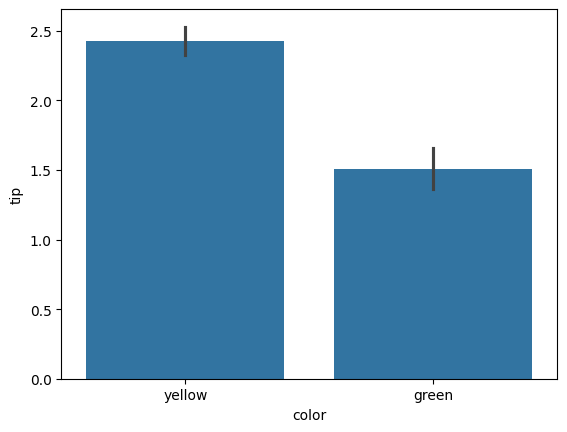

In [20]:
#graphical analysis of categorical
sns.barplot(x='color',y='tip',data=df,estimator='std')


<Axes: xlabel='color', ylabel='tip'>

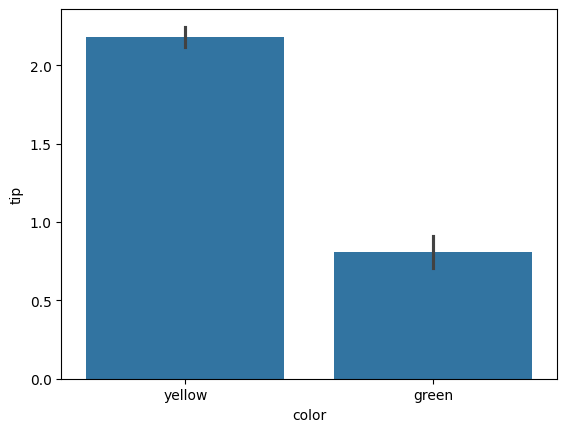

In [21]:
sns.barplot(x='color',y='tip',data=df,estimator='mean')

<Axes: xlabel='tip', ylabel='Count'>

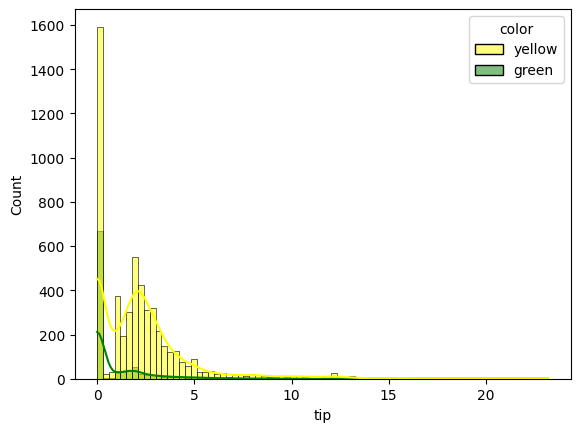

In [22]:
import matplotlib.pyplot as plt

sns.histplot(x=df.tip,hue=df.color,kde=True,palette=['yellow', 'green'])

**Hypotheses:**  
- H0: distribution of tip for yellow = distribution of tip of green
- H1:distribution of tip for yellow != distribution of tip of green

In [23]:
yellow_tip = df['tip'][df['color']=='yellow']
green_tip = df['tip'][df['color']=='green']
print(yellow_tip)
print(green_tip)

0       2.15
1       0.00
2       2.36
3       6.15
4       1.10
        ... 
5446    2.66
5447    2.36
5448    2.56
5449    2.36
5450    1.33
Name: tip, Length: 5373, dtype: float64
5451    0.00
5452    0.00
5453    1.20
5454    0.00
5455    0.00
        ... 
6428    1.06
6429    0.00
6430    0.00
6431    0.00
6432    3.36
Name: tip, Length: 968, dtype: float64


In [24]:
# Independent T-Test
from scipy import stats

t_stat, p_val = stats.ttest_ind(yellow_tip, green_tip)
#print("Independent T-Test statistic:", t_stat)
print("P-value:", p_val)



P-value: 7.791088119489451e-64


In [25]:
alpha = 0.05
if p_val < alpha:
    print("Reject null hypothesis: the tip for yellow category is different that of green")
else:
    print("Fail to reject null hypothesis")

Reject null hypothesis: the tip for yellow category is different that of green


In [26]:
#tip is numerical feature,analyse with payment feature with categorical
df.payment.value_counts()


,count
payment,
credit card,4546
cash,1795


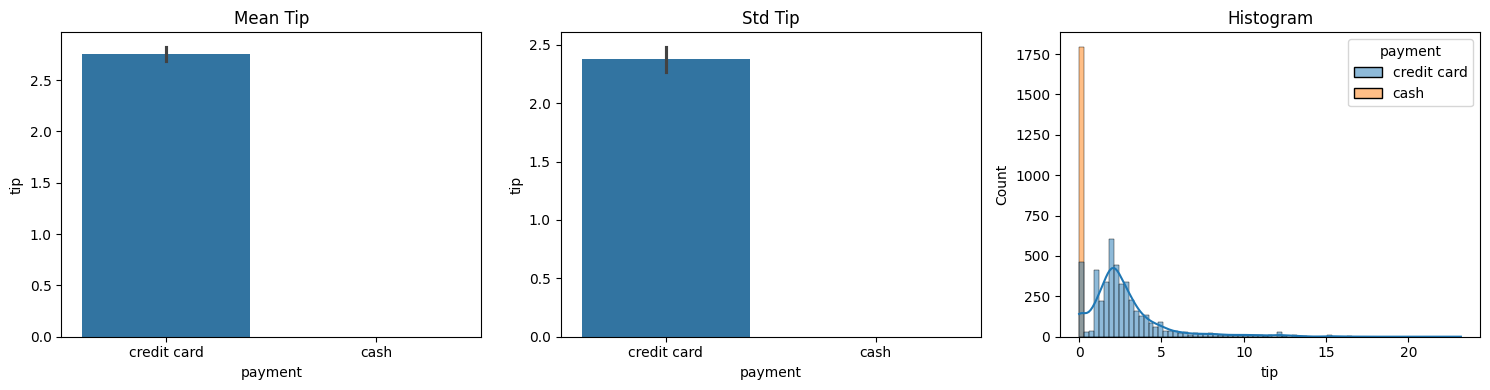

In [27]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,3, figsize=(15,4))
sns.barplot(x='payment', y='tip', data=df, estimator='mean', ax=axes[0])
axes[0].set_title("Mean Tip")
sns.barplot(x='payment', y='tip', data=df, estimator='std', ax=axes[1])
axes[1].set_title("Std Tip")

sns.histplot(data=df, x='tip', hue='payment', kde=True, ax=axes[2])
axes[2].set_title("Histogram")

plt.tight_layout()
plt.show()

Hypotheses:

H0: distribution of tip for credit card= distribution of tip of cash
H1:distribution of tip for credit card != distribution of tip of cash

In [28]:
credit_tip = df['tip'][df['payment']=='credit card']
cash_tip = df['tip'][df['payment']=='cash']


In [29]:
# Independent T-Test
from scipy import stats

t_stat, p_val = stats.ttest_ind(credit_tip, cash_tip)
#print("Independent T-Test statistic:", t_stat)
print("P-value:", p_val)

P-value: 0.0


In [30]:
alpha = 0.05
if p_val < alpha:
    print("Reject null hypothesis: the tip for credit card payment category is different that of cash ")
else:
    print("Fail to reject null hypothesis")

Reject null hypothesis: the tip for credit card payment category is different that of cash 


In [31]:
df['pickup_borough'].unique()

array(['Manhattan', 'Queens', 'Bronx', 'Brooklyn'], dtype=object)

In [32]:
df['pickup_borough'].value_counts()

,count
pickup_borough,
Manhattan,5226
Queens,638
Brooklyn,378
Bronx,99


/tmp/ipython-input-3733200601.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['pickup_borough'], palette='Set2') #univariant


<Axes: xlabel='pickup_borough', ylabel='count'>

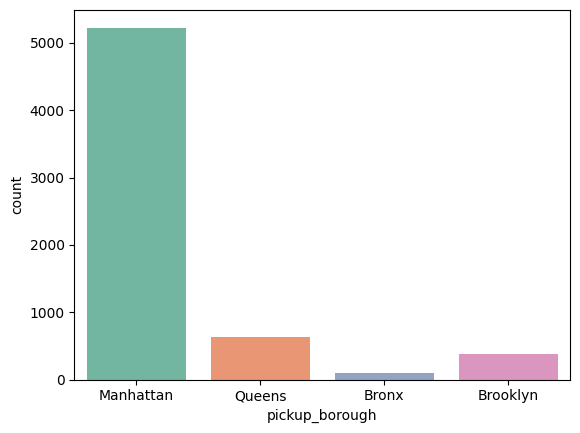

In [33]:
sns.countplot(x=df['pickup_borough'], palette='Set2') #univariant

/tmp/ipython-input-483514082.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['pickup_borough'], y=df['tip'], palette='Set2')


<Axes: xlabel='pickup_borough', ylabel='tip'>

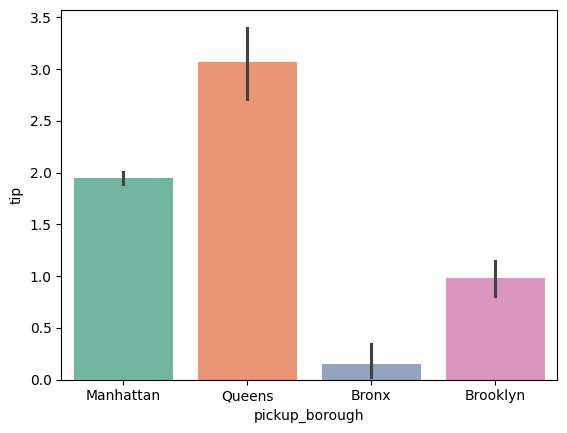

In [34]:
sns.barplot(x=df['pickup_borough'], y=df['tip'], palette='Set2')

/tmp/ipython-input-2605922404.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['pickup_borough'], y=df['tip'], palette='Set2',estimator='mean')


<Axes: xlabel='pickup_borough', ylabel='tip'>

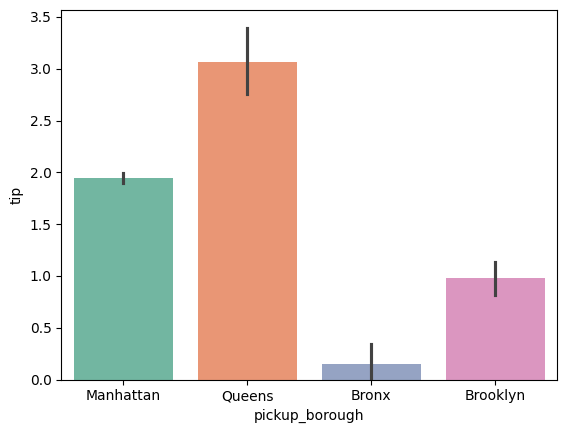

In [35]:
sns.barplot(x=df['pickup_borough'], y=df['tip'], palette='Set2',estimator='mean')

/tmp/ipython-input-1597738132.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['pickup_borough'], y=df['tip'], palette='Set2',estimator='std')


<Axes: xlabel='pickup_borough', ylabel='tip'>

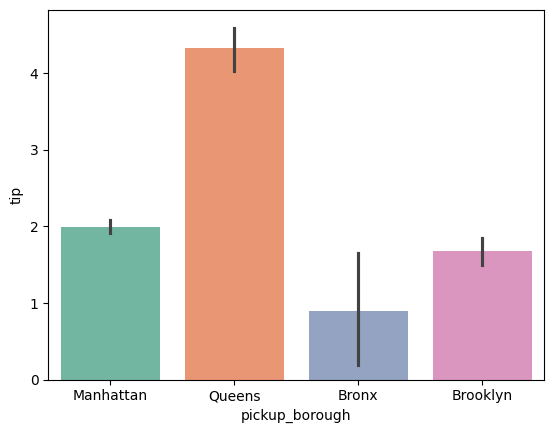

In [36]:
sns.barplot(x=df['pickup_borough'], y=df['tip'], palette='Set2',estimator='std')

In [37]:
df['tip'].groupby(df['pickup_borough']).mean()

,tip
pickup_borough,
Bronx,0.148586
Brooklyn,0.979127
Manhattan,1.945597
Queens,3.066458


In [38]:
df['tip'].groupby(df['pickup_borough']).std()

,tip
pickup_borough,
Bronx,0.897261
Brooklyn,1.674487
Manhattan,1.997736
Queens,4.323951


<Axes: xlabel='tip', ylabel='Count'>

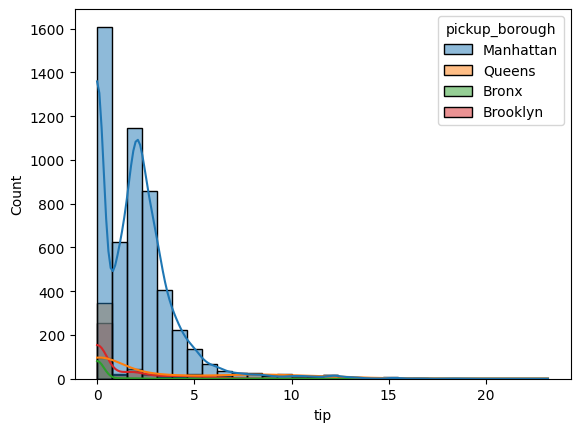

In [39]:
sns.histplot  (x=df['tip'], hue=df['pickup_borough'], kde=True,bins=30)

**hypothesis**

h0 : distribution of tip is the same across all pickup_borough categories

h1 : at least one category has a different distribution of *tip*

In [40]:
from scipy import stats

# Separate tip values by borough
manhattan_tip = df.loc[df['pickup_borough'] == 'Manhattan', 'tip']
queens_tip    = df.loc[df['pickup_borough'] == 'Queens', 'tip']
bronx_tip     = df.loc[df['pickup_borough'] == 'Bronx', 'tip']
brooklyn_tip  = df.loc[df['pickup_borough'] == 'Brooklyn', 'tip']


In [41]:

# One-way ANOVA
f_stat, p_val = stats.f_oneway(
    manhattan_tip,
    queens_tip,
    bronx_tip,
    brooklyn_tip
)

print('F-statistic:', f_stat)
print('p-value:', p_val)


F-statistic: 91.5793383185057
p-value: 5.155109332422435e-58


In [42]:
alpha = 0.05
if p_val < alpha:
    print("Reject null hypothesis")
else:
    print("Fail to reject null hypothesis")

Reject null hypothesis


Hypotheses (for each pair of boroughs):

H0: Distribution (mean tip) of group1 = distribution of group2

H1: Distribution (mean tip) of group1 ≠ distribution of group2

In [43]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD test
tukey_result = pairwise_tukeyhsd(
    endog=df['tip'],
    groups=df['pickup_borough'],
    alpha=0.05
)

# Print results
print(tukey_result)


  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
  group1    group2  meandiff p-adj lower  upper  reject
-------------------------------------------------------
    Bronx  Brooklyn   0.8305 0.008 0.1595 1.5015   True
    Bronx Manhattan    1.797   0.0  1.194    2.4   True
    Bronx    Queens   2.9179   0.0 2.2759 3.5599   True
 Brooklyn Manhattan   0.9665   0.0 0.6499  1.283   True
 Brooklyn    Queens   2.0873   0.0 1.7016 2.4731   True
Manhattan    Queens   1.1209   0.0 0.8716 1.3701   True
-------------------------------------------------------


In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd


In [45]:
df['dropoff_borough'].unique()
df['dropoff_borough'].value_counts()


,count
dropoff_borough,
Manhattan,5172
Queens,534
Brooklyn,497
Bronx,136
Staten Island,2


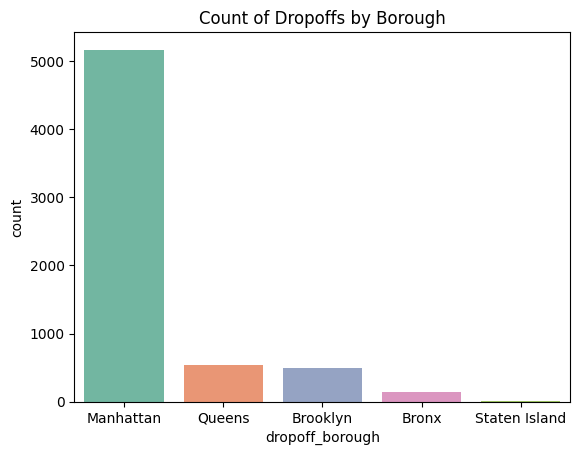

In [46]:
sns.countplot(
    x='dropoff_borough',
    hue='dropoff_borough',
    data=df,
    palette='Set2',
    legend=False
)
plt.title("Count of Dropoffs by Borough")
plt.show()


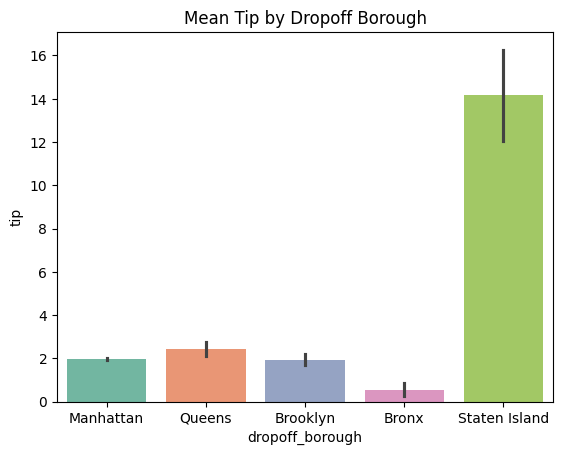

In [47]:
sns.barplot(
    x='dropoff_borough',
    y='tip',
    hue='dropoff_borough',
    data=df,
    palette='Set2',
    estimator='mean',
    legend=False
)
plt.title("Mean Tip by Dropoff Borough")
plt.show()


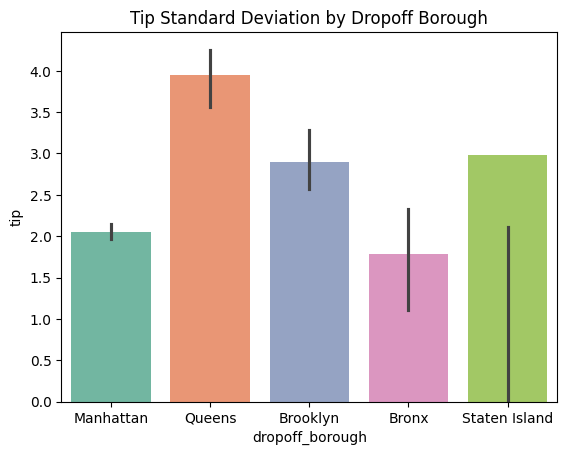

In [48]:
sns.barplot(
    x='dropoff_borough',
    y='tip',
    hue='dropoff_borough',
    data=df,
    palette='Set2',
    estimator='std',
    legend=False
)
plt.title("Tip Standard Deviation by Dropoff Borough")
plt.show()


In [49]:
df.groupby('dropoff_borough')['tip'].mean()
df.groupby('dropoff_borough')['tip'].std()


,tip
dropoff_borough,
Bronx,1.788795
Brooklyn,2.896229
Manhattan,2.052074
Queens,3.947016
Staten Island,2.976920


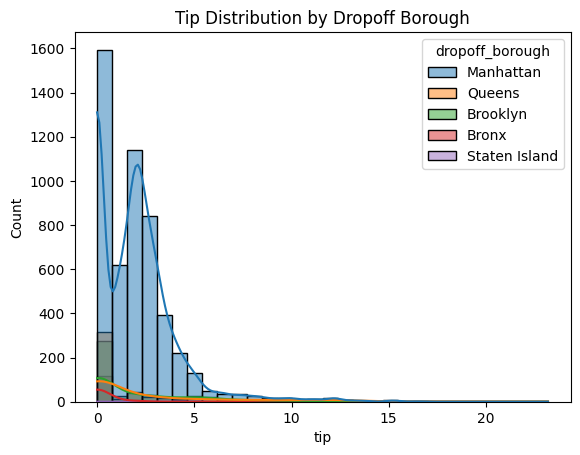

In [50]:
sns.histplot(
    data=df,
    x='tip',
    hue='dropoff_borough',
    kde=True,
    bins=30
)
plt.title("Tip Distribution by Dropoff Borough")
plt.show()


Hypotheses

H₀: Mean tip is the same across all dropoff boroughs

H₁: At least one dropoff borough has a different mean tip

In [51]:
from scipy import stats

# Create list of tip arrays by dropoff borough
categories = [
    group['tip'].dropna().values
    for _, group in df.groupby('dropoff_borough')
]

# One-way ANOVA (use * to unpack)
f_stat, p_val = stats.f_oneway(*categories)

print("F-statistic:", f_stat)
print("p-value:", p_val)


F-statistic: 31.42417796696828
p-value: 5.87859571331583e-26


In [52]:
alpha = 0.05
if p_val < alpha:
    print("Reject null hypothesis")
else:
    print("Fail to reject null hypothesis")

Reject null hypothesis


In [53]:
alpha = 0.05

if p_val < alpha:
    print("Reject H0: Mean tips differ by dropoff borough.\n")

    tukey_result = pairwise_tukeyhsd(
        endog=df['tip'],
        groups=df['dropoff_borough'],
        alpha=alpha
    )
    print(tukey_result)

else:
    print("Fail to reject H0: No significant difference in mean tips.")


Reject H0: Mean tips differ by dropoff borough.

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1      group2    meandiff p-adj   lower   upper  reject
--------------------------------------------------------------
    Bronx      Brooklyn   1.3869    0.0  0.7691  2.0046   True
    Bronx     Manhattan   1.4296    0.0  0.8751  1.9842   True
    Bronx        Queens   1.8873    0.0  1.2742  2.5005   True
    Bronx Staten Island  13.6303    0.0  9.0833 18.1773   True
 Brooklyn     Manhattan   0.0427 0.9952 -0.2571  0.3425  False
 Brooklyn        Queens   0.5004 0.0055  0.1026  0.8983   True
 Brooklyn Staten Island  12.2434    0.0  7.7204 16.7664   True
Manhattan        Queens   0.4577 0.0002  0.1675  0.7479   True
Manhattan Staten Island  12.2007    0.0  7.6859 16.7154   True
   Queens Staten Island   11.743    0.0  7.2206 16.2653   True
--------------------------------------------------------------


In [54]:
from scipy import stats


categories = [
    group['tip'].dropna().values
    for _, group in df.groupby('pickup_zone')
]

# One-way ANOVA (use * to unpack)
f_stat, p_val = stats.f_oneway(*categories)

print("F-statistic:", f_stat)
print("p-value:", p_val)
alpha = 0.05
if p_val < alpha:
    print("Reject null hypothesis")
else:
    print("Fail to reject null hypothesis")


F-statistic: 7.563376210961916
p-value: 7.892434822136223e-169
Reject null hypothesis


In [55]:
from scipy import stats


categories = [
    group['tip'].dropna().values
    for _, group in df.groupby('dropoff_zone')
]

# One-way ANOVA (use * to unpack)
f_stat, p_val = stats.f_oneway(*categories)

print("F-statistic:", f_stat)
print("p-value:", p_val)
alpha = 0.05
if p_val < alpha:
    print("Reject null hypothesis")
else:
    print("Fail to reject null hypothesis")


F-statistic: 5.76903467327541
p-value: 1.3107168403745948e-120
Reject null hypothesis


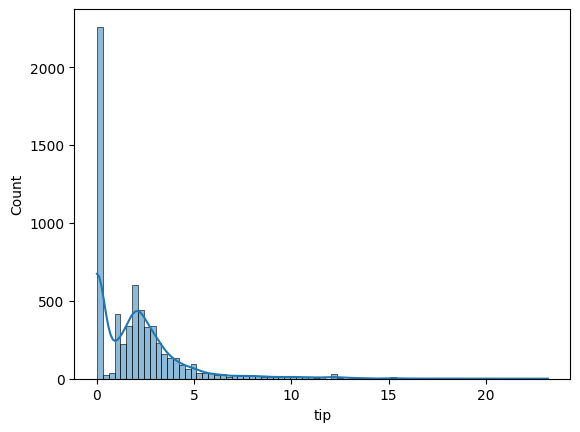

In [56]:
sns.histplot(df['tip'],kde=True)
plt.show()

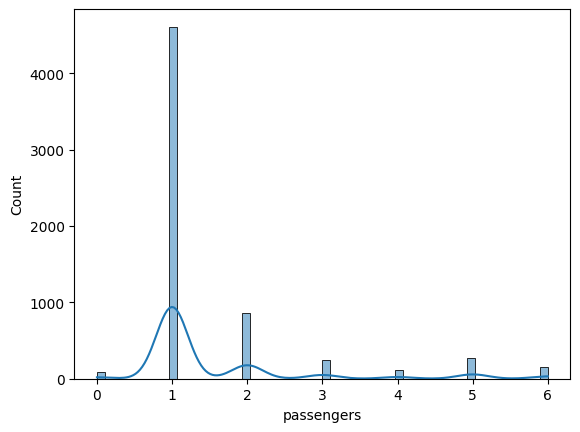

In [57]:
sns.histplot(df['passengers'],kde=True)
plt.show()

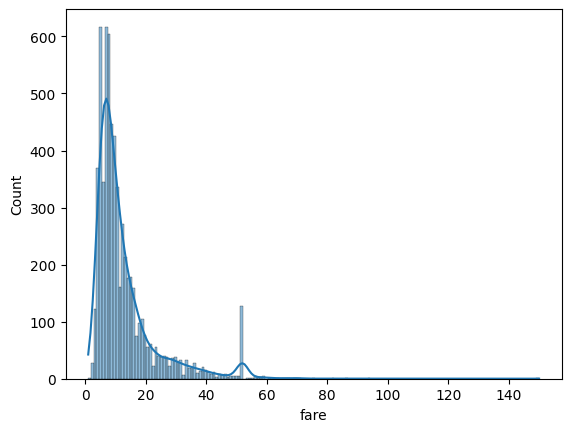

In [58]:
sns.histplot(df['fare'],kde=True)
plt.show()

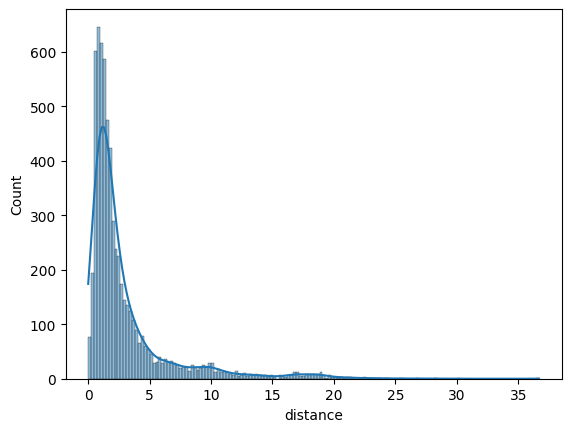

In [59]:
sns.histplot(df['distance'],kde=True)
plt.show()

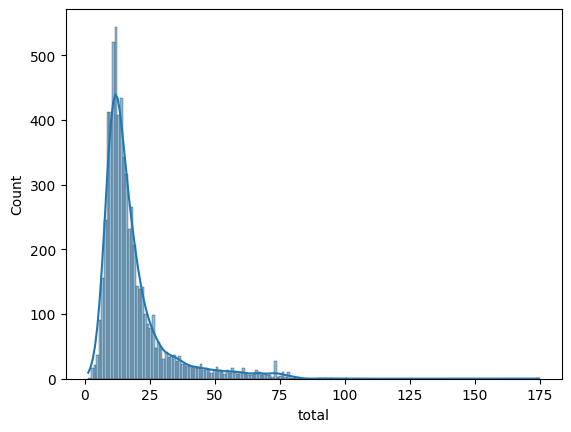

In [60]:
sns.histplot(df['total'],kde=True)
plt.show()

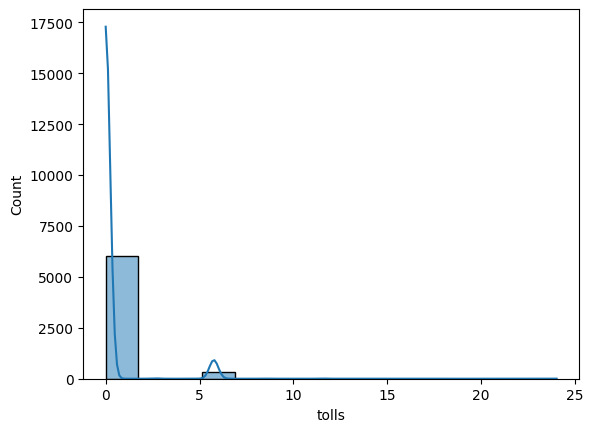

In [61]:
sns.histplot(df['tolls'],kde=True)
plt.show()

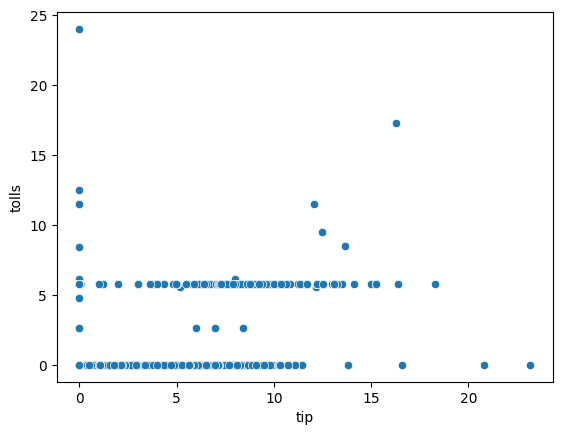

In [62]:
sns.scatterplot(x=df.tip,y=df.tolls)
plt.show()

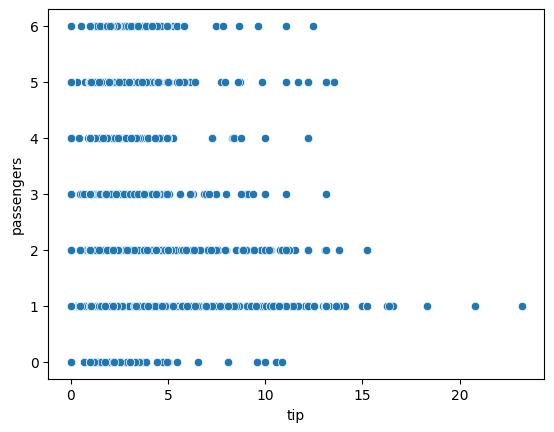

In [63]:
sns.scatterplot(x=df.tip,y=df.passengers)
plt.show()

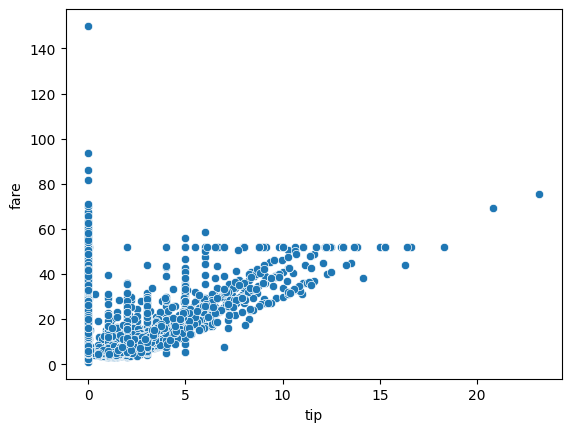

In [64]:
sns.scatterplot(x=df.tip,y=df.fare)
plt.show()

Pearson Correlation Test

 Hypotheses:

H0 (Null Hypothesis): Correlation between tip and fare is zero
                    (ρ = 0)

                    
H1 (Alternative Hypothesis): Correlation between tip and fare is not zero
                           (ρ ≠ 0)

In [86]:
df.passengers.skew()

np.float64(2.349366327837006)

In [85]:
df.passengers.kurtosis()

np.float64(4.8167003036423175)

In [65]:
# Compute Pearson correlation
r, p_val = stats.pearsonr(df['tip'], df['passengers'])

print("Correlation coefficient (r):", r)
print("P-value:", p_val)

# Significance level
alpha = 0.05

# Decision rule
if p_val < alpha:
    print("Reject null hypothesis: Significant correlation exists.")
else:
    print("Fail to reject null hypothesis: No significant correlation.")

Correlation coefficient (r): 0.017838280361313713
P-value: 0.15551969503298518
Fail to reject null hypothesis: No significant correlation.


In [66]:

r, p_val = stats.spearmanr(df['tip'], df['passengers'])

print("Correlation coefficient (r):", r)
print("P-value:", p_val)

# Significance level
alpha = 0.05

# Decision rule
if p_val < alpha:
    print("Reject null hypothesis: there is no relationship.")
else:
    print("Fail to reject null hypothesis: No significant correlation.")

Correlation coefficient (r): 0.027509812818779178
P-value: 0.028480753176042872
Reject null hypothesis: there is no relationship.


In [87]:
df.fare.skew()

np.float64(2.606558389580325)

In [88]:
df.fare.kurtosis()

np.float64(10.170827993181963)

In [67]:

r, p_val = stats.spearmanr(df['tip'], df['fare'])

print("Correlation coefficient (r):", r)
print("P-value:", p_val)

# Significance level
alpha = 0.05

# Decision rule
if p_val < alpha:
    print("Reject null hypothesis: there is no relationship.")
else:
    print("Fail to reject null hypothesis: No significant correlation.")

Correlation coefficient (r): 0.310254279563729
P-value: 1.5556730728881364e-141
Reject null hypothesis: there is no relationship.


In [68]:
# Compute Pearson correlation
r, p_val = stats.pearsonr(df['tip'], df['fare'])

print("Correlation coefficient (r):", r)
print("P-value:", p_val)

# Significance level
alpha = 0.05

# Decision rule
if p_val < alpha:
    print("Reject null hypothesis: Significant correlation exists.")
else:
    print("Fail to reject null hypothesis: No significant correlation.")

Correlation coefficient (r): 0.48710089077355956
P-value: 0.0
Reject null hypothesis: Significant correlation exists.


In [89]:
df.total.skew()

np.float64(2.635965898086771)

In [90]:
df.total.kurtosis()

np.float64(9.67290848630777)

In [76]:

r, p_val = stats.spearmanr(df['tip'], df['total'])

print("Correlation coefficient (r):", r)
print("P-value:", p_val)

# Significance level
alpha = 0.05

# Decision rule
if p_val < alpha:
    print("Reject null hypothesis: there is no relationship.")
else:
    print("Fail to reject null hypothesis: No significant correlation.")

Correlation coefficient (r): 0.5028299699182296
P-value: 0.0
Reject null hypothesis: there is no relationship.


In [69]:
# Compute Pearson correlation
r, p_val = stats.pearsonr(df['tip'], df['total'])

print("Correlation coefficient (r):", r)
print("P-value:", p_val)

# Significance level
alpha = 0.05

# Decision rule
if p_val < alpha:
    print("Reject null hypothesis: Significant correlation exists.")
else:
    print("Fail to reject null hypothesis: No significant correlation.")

Correlation coefficient (r): 0.6506766365313064
P-value: 0.0
Reject null hypothesis: Significant correlation exists.


In [91]:
df.distance.skew()

np.float64(2.8870233381954415)

In [92]:
df.distance.kurtosis()

np.float64(9.793001481080482)

In [77]:
# Compute Pearson correlation
r, p_val = stats.pearsonr(df['tip'], df['distance'])

print("Correlation coefficient (r):", r)
print("P-value:", p_val)

# Significance level
alpha = 0.05

# Decision rule
if p_val < alpha:
    print("Reject null hypothesis: Significant correlation exists.")
else:
    print("Fail to reject null hypothesis: No significant correlation.")

Correlation coefficient (r): 0.4769796821455606
P-value: 0.0
Reject null hypothesis: Significant correlation exists.


In [74]:

r, p_val = stats.spearmanr(df['tip'], df['distance'])

print("Correlation coefficient (r):", r)
print("P-value:", p_val)

# Significance level
alpha = 0.05

# Decision rule
if p_val < alpha:
    print("Reject null hypothesis: there is no relationship.")
else:
    print("Fail to reject null hypothesis: No significant correlation.")

Correlation coefficient (r): 0.29265085410043695
P-value: 1.9411181331374707e-125
Reject null hypothesis: there is no relationship.


In [93]:
df.tolls.skew()

np.float64(4.876125068610457)

In [94]:
df.tolls.kurtosis()

np.float64(32.159491595605495)

In [70]:

r, p_val = stats.spearmanr(df['tip'], df['tolls'])

print("Correlation coefficient (r):", r)
print("P-value:", p_val)

# Significance level
alpha = 0.05

# Decision rule
if p_val < alpha:
    print("Reject null hypothesis: there is no relationship.")
else:
    print("Fail to reject null hypothesis: No significant correlation.")

Correlation coefficient (r): 0.175380002891528
P-value: 5.643276180955435e-45
Reject null hypothesis: there is no relationship.


In [78]:
from scipy import stats
# Compute Pearson correlation
r, p_val = stats.pearsonr(df['tip'], df['tolls'])

print("Correlation coefficient (r):", r)
print("P-value:", p_val)

# Significance level
alpha = 0.05

# Decision rule
if p_val < alpha:
    print("Reject null hypothesis: Significant correlation exists.")
else:
    print("Fail to reject null hypothesis: No significant correlation.")

Correlation coefficient (r): 0.41467000187389874
P-value: 4.5828986386065086e-262
Reject null hypothesis: Significant correlation exists.


In [81]:
nm=df[['fare','tip','tolls','distance','total','passengers']]

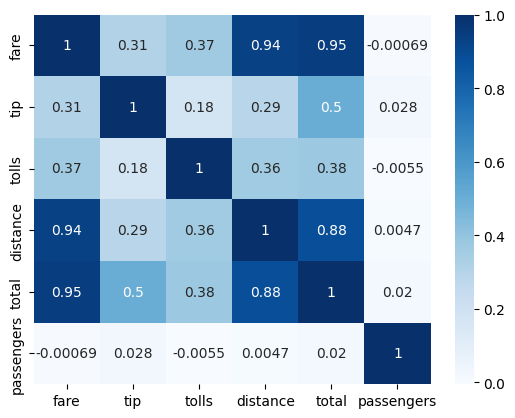

In [82]:
sns.heatmap(nm.corr(method='spearman'),annot=True,cmap="Blues")
plt.show()